# Dataset Overview


In [ ]:
import os
import json
import pandas as pd

# requires the data from Zenodo
with open("data/divers1m_json/rich/divers1m.json", "r") as f:
    data = json.load(f)
    
df = pd.DataFrame.from_dict(data["info"], orient="index")
df["dvi"] = df.apply(lambda row: not (row.version in row.filename), axis=1)

# get the split into the dataframe
clique2split = {}
for split_name, split_dict in data["split"].items():
    for clique_id in split_dict.keys():
        clique2split[clique_id] = split_name
df["split"] = df["clique"].map(clique2split)



## Tabular Overview

In [2]:
def print_df_summary(df, subset="overall"):
    if subset != "overall":
        df = df.query(f"split == '{subset}'")
    print(f"Summary statistics for {subset}")

    # Column stats
    stats = []
    for col in ["clique", "version", "youtube_id"]:
        unique_count = df[col].nunique()
        total_count = df[col].count()
        stats.append(f"{col:<12} | Unique: {unique_count:>7,} | Total: {total_count:>7,}")
    print("\n".join(stats))

    # Version per clique stats
    version_per_clique = df.groupby("clique")["version"].nunique()
    print("\nVersion per clique:")
    print(f"  Min: {version_per_clique.min():>3}  | Max: {version_per_clique.max():>3}  | "
          f"Mean: {version_per_clique.mean():>5.2f}  | Median: {version_per_clique.median():>5.2f}  | "
          f"Std: {version_per_clique.std():>5.2f}")
    print("=" * 40)
    
print_df_summary(df, "overall")


Summary statistics for overall
clique       | Unique:  93,764 | Total: 1,244,810
version      | Unique: 1,244,810 | Total: 1,244,810
youtube_id   | Unique: 1,244,810 | Total: 1,244,810

Version per clique:
  Min:   2  | Max: 612  | Mean: 13.28  | Median:  5.00  | Std: 20.41


In [3]:
print_df_summary(df, "train")
print_df_summary(df, "valid")
print_df_summary(df, "test")


Summary statistics for train
clique       | Unique:  75,074 | Total: 935,481
version      | Unique: 935,481 | Total: 935,481
youtube_id   | Unique: 935,481 | Total: 935,481

Version per clique:
  Min:   2  | Max: 472  | Mean: 12.46  | Median:  5.00  | Std: 18.23
Summary statistics for valid
clique       | Unique:   8,344 | Total: 102,350
version      | Unique: 102,350 | Total: 102,350
youtube_id   | Unique: 102,350 | Total: 102,350

Version per clique:
  Min:   2  | Max: 249  | Mean: 12.27  | Median:  4.00  | Std: 17.87
Summary statistics for test
clique       | Unique:  10,346 | Total: 206,979
version      | Unique: 206,979 | Total: 206,979
youtube_id   | Unique: 206,979 | Total: 206,979

Version per clique:
  Min:   2  | Max: 612  | Mean: 20.01  | Median:  6.00  | Std: 32.47


## Clique Size Distribution Plots

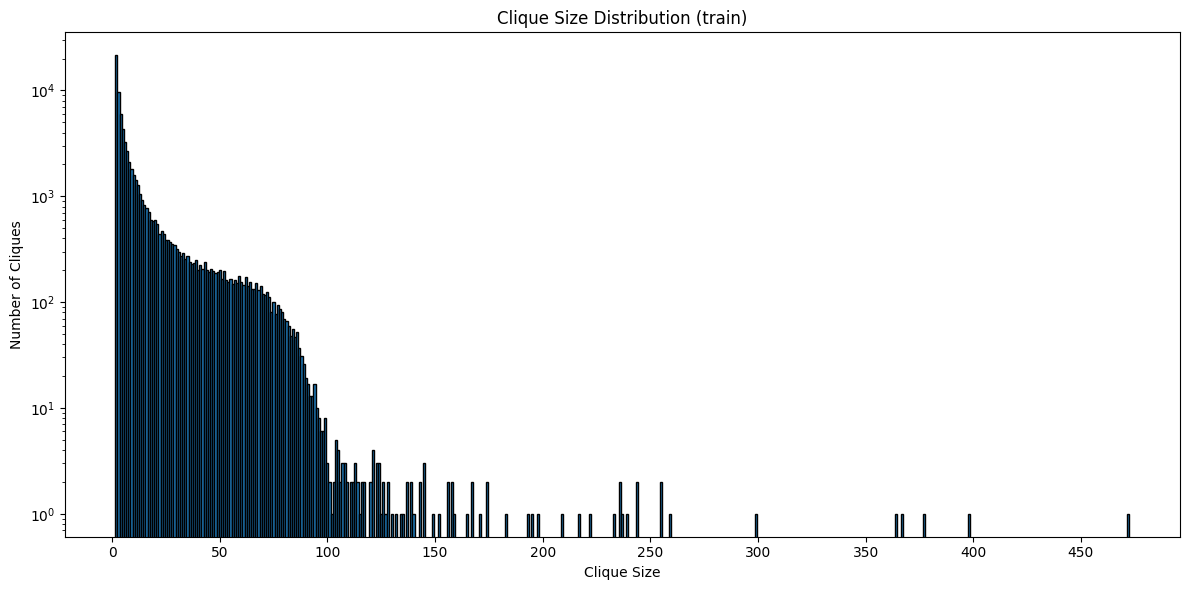

In [22]:
import matplotlib.pyplot as plt
import numpy as np


def plot_clique_size_distribution(df, subset="overall"):
    # filter
    if subset != "overall":
        df = df.query(f"split == '{subset}'")
    
    # get distribution
    sizes = df.clique.value_counts()
    size_distribution = sizes.value_counts().sort_index()

    # plot
    fig, ax = plt.subplots(figsize=(12,6))
    ax.bar(size_distribution.index, size_distribution.values, width=1.0, edgecolor='black')
    ax.set_xlabel('Clique Size')
    ax.set_ylabel('Number of Cliques')
    ax.set_title(f'Clique Size Distribution ({subset})')
    ax.set_yscale('log')
    
    # xticks
    step = 50
    ticks = range(0, size_distribution.index.max() + 1, step)
    ax.set_xticks(ticks)
    
    plt.tight_layout()
    plt.show()
    
plot_clique_size_distribution(df, "train")


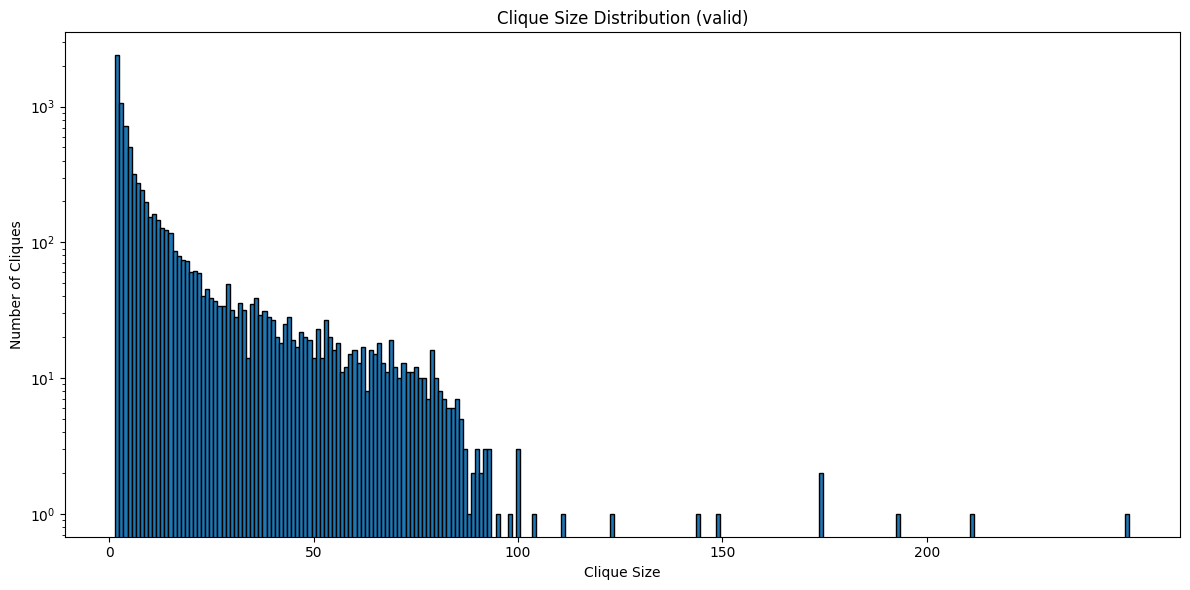

In [23]:
plot_clique_size_distribution(df, "valid")


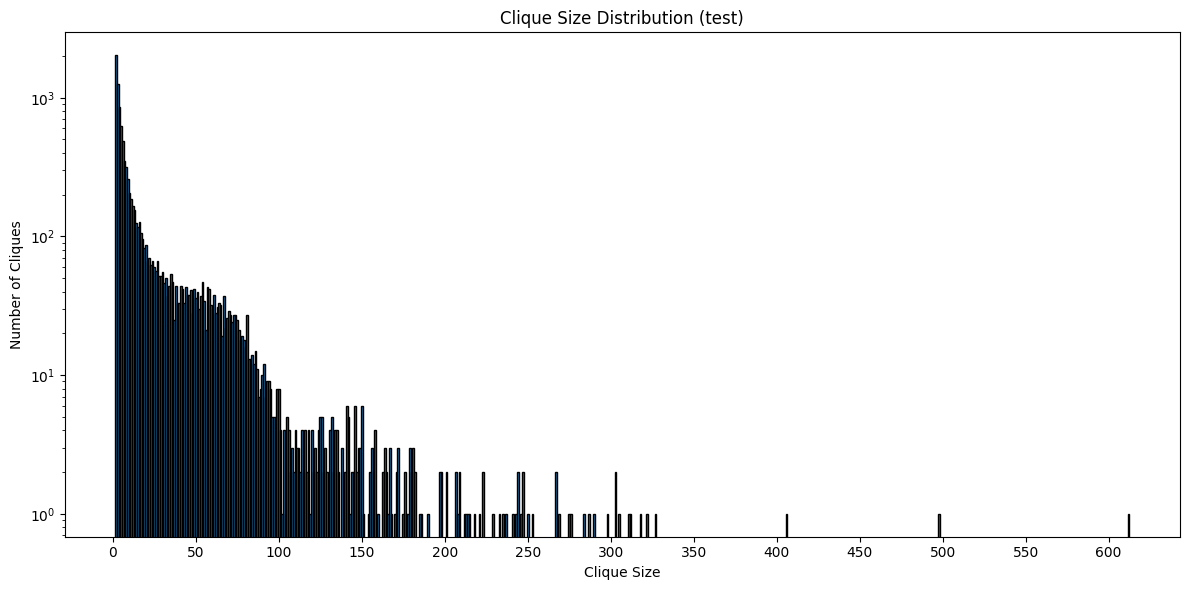

In [24]:
plot_clique_size_distribution(df, "test")

## Further Insights

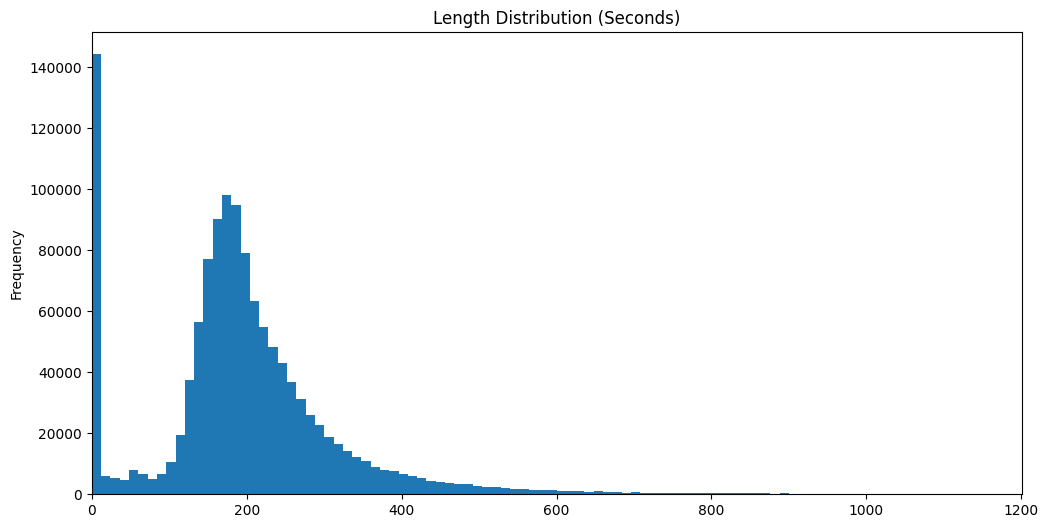

In [55]:
import seaborn as sns

df.plot.hist(column="length", bins=100, figsize=(12,6))
plt.legend([],[], frameon=False)
plt.xlim(0, df["length"].max() + 1)
plt.title('Length Distribution (Seconds)')
plt.show()


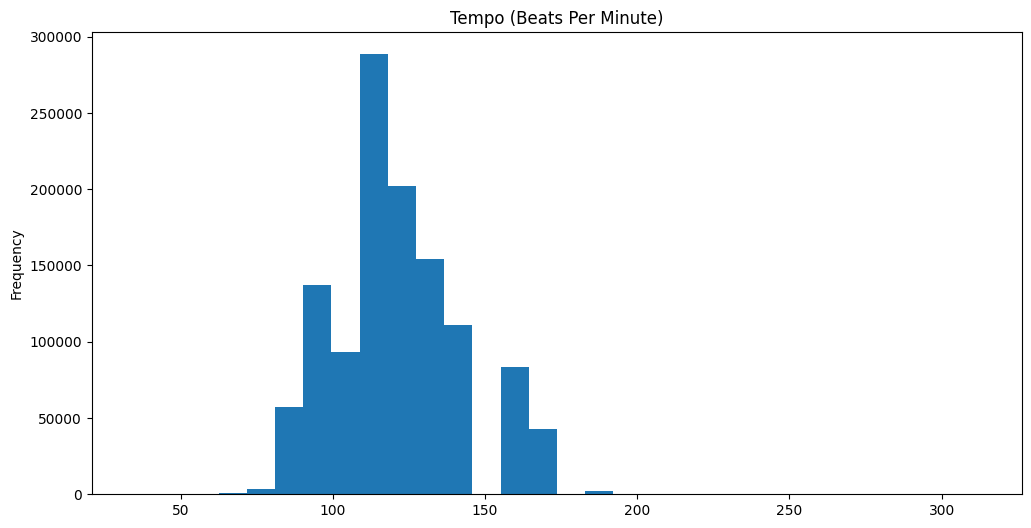

In [56]:
df.plot.hist(column="tempo", bins=30, figsize=(12,6))
plt.legend([],[], frameon=False)
plt.title('Tempo (Beats Per Minute)')
plt.show()
